# Diffusion Language Models and Causal Reward Shaping


> Causal reasoning trajectories for diffusion language models with reward shaping.

It uses a ready-to-load diffusion language model instead of building a DLM from scratch. The default is `nvidia/Efficient-DLM-4B`, because its generation API exposes diffusion-specific controls such as `steps`, `block_length`, `threshold`, and `nfe`.

The practical question is not simply whether the model answers correctly. The question is whether the denoising trajectory stays semantically and causally aligned with the prompt as extra test-time compute is added.

This notebook therefore compares multiple denoising schedules and scores each output with lightweight diagnostics for semantic drift, answer stability, redundancy, and counterfactual sensitivity.

## Why This Notebook Is Written This Way

Diffusion language models generate text by iterative denoising rather than strict left-to-right decoding. That creates useful flexibility, but it also creates the exact failure mode in your notes: with more denoising steps or more aggressive exploration, the latent trajectory can remain smooth while the decoded text drifts away from the causal state of the problem.

So this notebook is an instrumentation harness:

1. Load a real ready-to-use DLM.
2. Run the same reasoning prompt under different denoising schedules.
3. Measure whether extra denoising improves or damages semantic alignment.
4. Compare original prompts against counterfactual edits.
5. Build a simple reward-shaping table that can later become an RL objective.

The notebook deliberately avoids claiming that text-level metrics prove causal faithfulness. They are proxies. The point is to make the verification gap measurable enough to design better experiments.

In [1]:
# Run this first in Colab, then restart the runtime before running the model-load cell.
# Efficient-DLM remote code needs Transformers 4.x APIs; 5.x can break this pinned model revision.
%pip install -U "transformers>=4.57.1,<5" accelerate datasets pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 98.4 MB/s eta 0:00:00ta 0:00:01
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.14.0
    Uninstalling huggingface_hub-1.14.0:
      Successfully uninstalled huggingface_hub-1.14.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.8.1
    Uninstalling transformers-5.8.1:
      Successfully uninstalled transformers-5.8.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


## Configuration

`nvidia/Efficient-DLM-4B` is the default because it is smaller than most 7B/8B DLMs and exposes diffusion-specific generation controls.

If you have more VRAM, you can try:

- `nvidia/Efficient-DLM-8B`
- `Dream-org/Dream-v0-Instruct-7B`
- `GSAI-ML/LLaDA-8B-Instruct`

These models use custom code. Keep `trust_remote_code=True` only for model repos you intentionally trust.

In [2]:
import json
import math
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

MODEL_ID = "nvidia/Efficient-DLM-4B"
MODEL_REVISION = "d28c3167e0972d9c08eb92e03cb40a42d14690d5"
HF_CACHE_DIR = Path("hf_cache")
HF_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR.resolve()))
os.environ.setdefault("HF_DATASETS_CACHE", str((HF_CACHE_DIR / "datasets").resolve()))

RUN_GENERATION = True
MAX_NEW_TOKENS = 160

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32
print("device:", device)
print("dtype:", dtype)
print("model:", MODEL_ID)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

device: cuda
dtype: torch.bfloat16
model: nvidia/Efficient-DLM-4B


## Load the Ready DLM

The model is loaded with `AutoModel` rather than `AutoModelForCausalLM` because diffusion LMs often expose custom generation methods through remote model code.

Efficient-DLM currently needs newer Transformers APIs. If you see either of these errors:

- `cannot import name SlidingWindowCache`
- `cannot import name use_kernel_forward_from_hub`

then your kernel is still using an older `transformers` package. Run the install cell above, then restart the notebook kernel/runtime. In Colab, use `Runtime -> Restart runtime`.

The important practical output is that `model.generate(...)` accepts diffusion controls. For Efficient-DLM, the relevant ones are:

- `steps`: denoising/refinement budget.
- `block_length`: blockwise generation granularity.
- `threshold`: confidence threshold controlling acceptance/refinement.
- returned `nfe`: number of function evaluations.


In [3]:
import transformers
from packaging import version
from transformers import AutoConfig, AutoModel, AutoTokenizer
from transformers import cache_utils
import transformers.integrations as hf_integrations

MIN_TRANSFORMERS = "4.57.1"
MAX_TRANSFORMERS_MAJOR = 5
print("transformers:", transformers.__version__)

missing_api = []
if not hasattr(cache_utils, "SlidingWindowCache"):
    missing_api.append("transformers.cache_utils.SlidingWindowCache")
if not hasattr(hf_integrations, "use_kernel_forward_from_hub"):
    missing_api.append("transformers.integrations.use_kernel_forward_from_hub")

current_version = version.parse(transformers.__version__)
if current_version < version.parse(MIN_TRANSFORMERS) or current_version.major >= MAX_TRANSFORMERS_MAJOR or missing_api:
    raise ImportError(
        "Efficient-DLM cannot load with this Transformers install. "
        f"Found transformers=={transformers.__version__}; missing APIs: {missing_api}. "
        "Use Transformers 4.x for this model revision. "
        "Run the first install cell: %pip install -U \"transformers>=4.57.1,<5\" accelerate datasets pandas matplotlib, "
        "then restart the notebook kernel/runtime and rerun from the top."
    )

if device != "cuda":
    print("CUDA is not available. Loading a 4B DLM on CPU is usually impractical.")
    print("Set RUN_GENERATION=False if you only want to inspect the notebook.")

load_kwargs = dict(
    trust_remote_code=True,
    cache_dir=str(HF_CACHE_DIR),
)
if "MODEL_REVISION" in globals() and MODEL_REVISION:
    load_kwargs["revision"] = MODEL_REVISION

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, **load_kwargs)

if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token = tokenizer.eos_token

config = AutoConfig.from_pretrained(MODEL_ID, **load_kwargs)
if getattr(config, "pad_token_id", None) is None:
    config.pad_token_id = tokenizer.pad_token_id
if getattr(config, "eos_token_id", None) is None:
    config.eos_token_id = tokenizer.eos_token_id
if getattr(config, "bos_token_id", None) is None:
    config.bos_token_id = tokenizer.bos_token_id
if getattr(config, "vocab_size", None) is None:
    config.vocab_size = len(tokenizer)

model = AutoModel.from_pretrained(
    MODEL_ID,
    config=config,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
    **load_kwargs,
)
model = model.to(device).eval()
print("loaded", MODEL_ID)


transformers: 4.57.6


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


🚨 `replace_position` is part of Qwen3Model.forward's signature, but not documented. Make sure to add it to the docstring of the function in /content/hf_cache/modules/transformers_modules/nvidia/Efficient_hyphen_DLM_hyphen_4B/d28c3167e0972d9c08eb92e03cb40a42d14690d5/modeling_qwen3.py.
🚨 `is_training` is part of Qwen3Model.forward's signature, but not documented. Make sure to add it to the docstring of the function in /content/hf_cache/modules/transformers_modules/nvidia/Efficient_hyphen_DLM_hyphen_4B/d28c3167e0972d9c08eb92e03cb40a42d14690d5/modeling_qwen3.py.
🚨 `replace_position` is part of Qwen3ForCausalLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in /content/hf_cache/modules/transformers_modules/nvidia/Efficient_hyphen_DLM_hyphen_4B/d28c3167e0972d9c08eb92e03cb40a42d14690d5/modeling_qwen3.py.
🚨 `replace_position` is part of Qwen3DiffusionLM.forward's signature, but not documented. Make sure to add it to the docstring of the function i

generation_config.json:   0%|          | 0.00/91.0 [00:00<?, ?B/s]

loaded nvidia/Efficient-DLM-4B


## Reasoning Prompts and Counterfactual Pairs

The prompts are small by design. Each pair changes a causal variable while leaving most surface form unchanged. If the DLM is causally aligned, the answer should change in the right direction when the intervention changes the hidden state.

This lets us ask whether denoising schedules preserve the intervention-to-outcome map or merely generate plausible-looking reasoning.

In [4]:
PROMPT_PAIRS = [
    {
        "id": "price_intervention",
        "base": "A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.",
        "cf": "A notebook costs $5. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.",
        "base_answer": "8",
        "cf_answer": "5",
        "changed_terms": ["$4", "$5", "8", "5"],
    },
    {
        "id": "count_intervention",
        "base": "There are 18 apples. 6 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.",
        "cf": "There are 18 apples. 2 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.",
        "base_answer": "3",
        "cf_answer": "4",
        "changed_terms": ["6", "2", "3", "4"],
    },
    {
        "id": "rate_intervention",
        "base": "A machine packs 7 boxes per minute for 6 minutes. Then 5 boxes are removed. How many boxes remain? Show concise reasoning.",
        "cf": "A machine packs 9 boxes per minute for 6 minutes. Then 5 boxes are removed. How many boxes remain? Show concise reasoning.",
        "base_answer": "37",
        "cf_answer": "49",
        "changed_terms": ["7", "9", "37", "49"],
    },
]

SCHEDULES = [
    {"name": "fast", "steps": 32, "block_length": 32, "threshold": 0.8, "temperature": 0.2},
    {"name": "balanced", "steps": 64, "block_length": 32, "threshold": 0.9, "temperature": 0.2},
    {"name": "deep", "steps": 128, "block_length": 32, "threshold": 0.9, "temperature": 0.2},
    {"name": "exploratory", "steps": 128, "block_length": 32, "threshold": 0.7, "temperature": 0.7},
]

PROMPT_PAIRS[0]

{'id': 'price_intervention',
 'base': 'A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.',
 'cf': 'A notebook costs $5. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.',
 'base_answer': '8',
 'cf_answer': '5',
 'changed_terms': ['$4', '$5', '8', '5']}

## Generation Function

For Efficient-DLM, generation starts from the prompt and iteratively denoises a block of future tokens. We record text, latency, and NFE for each schedule.

If you switch to another DLM family, this is the main function you may need to adapt.

In [6]:
def _resolve_generation_constraints(schedule, max_new_tokens):
    block_length = int(schedule["block_length"])
    if block_length <= 0:
        raise ValueError(f"block_length must be > 0, got {block_length}")

    effective_max_new_tokens = int(max_new_tokens)
    if effective_max_new_tokens < block_length:
        effective_max_new_tokens = block_length
    remainder = effective_max_new_tokens % block_length
    if remainder != 0:
        effective_max_new_tokens -= remainder

    num_blocks = effective_max_new_tokens // block_length
    requested_steps = int(schedule["steps"])
    effective_steps = requested_steps
    if requested_steps % num_blocks != 0:
        effective_steps = ((requested_steps + num_blocks - 1) // num_blocks) * num_blocks

    return {
        "block_length": block_length,
        "num_blocks": num_blocks,
        "requested_steps": requested_steps,
        "effective_steps": effective_steps,
        "effective_max_new_tokens": effective_max_new_tokens,
    }


def generate_dlm(prompt, schedule):
    settings = _resolve_generation_constraints(schedule, MAX_NEW_TOKENS)
    if settings["effective_steps"] != settings["requested_steps"]:
        print(
            f"adjusting steps {settings['requested_steps']} -> {settings['effective_steps']} "
            f"for block_length={settings['block_length']} and max_new_tokens={settings['effective_max_new_tokens']}"
        )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    t0 = time.time()
    with torch.inference_mode():
        out = model.generate(
            inputs.input_ids,
            max_new_tokens=settings["effective_max_new_tokens"],
            steps=settings["effective_steps"],
            block_length=settings["block_length"],
            shift_logits=False,
            temperature=schedule["temperature"],
            threshold=schedule["threshold"],
        )
    elapsed = time.time() - t0
    if isinstance(out, tuple):
        out_ids, nfe = out
    else:
        out_ids, nfe = out, None
    completion = tokenizer.batch_decode(out_ids[:, inputs.input_ids.shape[-1]:], skip_special_tokens=True)[0]
    return {
        "completion": completion.strip(),
        "nfe": nfe,
        "seconds": elapsed,
        "requested_steps": settings["requested_steps"],
        "steps": settings["effective_steps"],
        "max_new_tokens": settings["effective_max_new_tokens"],
    }


def maybe_generate_all():
    rows = []
    if not RUN_GENERATION:
        print("RUN_GENERATION=False; skipping model calls.")
        return rows
    for pair in PROMPT_PAIRS:
        for variant_name, prompt, expected in [
            ("base", pair["base"], pair["base_answer"]),
            ("counterfactual", pair["cf"], pair["cf_answer"]),
        ]:
            for schedule in SCHEDULES:
                print(pair["id"], variant_name, schedule["name"])
                result = generate_dlm(prompt, schedule)
                rows.append({
                    "pair_id": pair["id"],
                    "variant": variant_name,
                    "prompt": prompt,
                    "expected": expected,
                    **schedule,
                    **result,
                })
    return rows


rows = maybe_generate_all() notebook costs $5. Maya 
len(rows)

price_intervention base fast
adjusting steps 32 -> 35 for block_length=32 and max_new_tokens=160
price_intervention base balanced
adjusting steps 64 -> 65 for block_length=32 and max_new_tokens=160
price_intervention base deep
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
price_intervention base exploratory
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
price_intervention counterfactual fast
adjusting steps 32 -> 35 for block_length=32 and max_new_tokens=160
price_intervention counterfactual balanced
adjusting steps 64 -> 65 for block_length=32 and max_new_tokens=160
price_intervention counterfactual deep
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
price_intervention counterfactual exploratory
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
count_intervention base fast
adjusting steps 32 -> 35 for block_length=32 and max_new_tokens=160
count_intervention base balanced
adjusting steps 64 -> 65

24

## Drift and Reward Proxies

These metrics are intentionally lightweight. They do not certify causal reasoning, but they expose failure modes:

- `answer_correct`: did the expected numeric answer appear near the end?
- `prompt_anchor_score`: how many important prompt terms are preserved in the completion?
- `redundancy`: repeated n-gram rate, a rough repetitive-tail signal.
- `length_penalty`: discourages overthinking and rambling.
- `causal_reward`: a shaped proxy combining correctness, anchor retention, and anti-redundancy.

The thesis point: when denoising gets more compute, you want reward to improve because reasoning is more aligned, not because the model produces longer plausible text.

In [7]:
STOPWORDS = set("a an the and or to of in for with is are does do did how many much show concise reasoning then rest per by among from".split())

def normalize_text(s):
    return re.sub(r"\s+", " ", s.lower()).strip()

def extract_numbers(s):
    return re.findall(r"-?\d+(?:\.\d+)?", s)

def answer_correct(completion, expected):
    nums = extract_numbers(completion)
    if not nums:
        return 0.0
    tail = nums[-4:]
    return float(str(expected) in tail)

def content_terms(prompt):
    terms = re.findall(r"[a-zA-Z0-9$]+", normalize_text(prompt))
    return [t for t in terms if t not in STOPWORDS and len(t) > 1]

def prompt_anchor_score(prompt, completion):
    terms = content_terms(prompt)
    if not terms:
        return 0.0
    c = normalize_text(completion)
    return sum(t in c for t in terms) / len(terms)

def repeated_ngram_rate(text, n=3):
    toks = re.findall(r"\w+", normalize_text(text))
    if len(toks) < n + 1:
        return 0.0
    grams = [tuple(toks[i:i+n]) for i in range(len(toks)-n+1)]
    return 1.0 - (len(set(grams)) / len(grams))

def length_penalty(completion, target_words=80):
    words = re.findall(r"\w+", completion)
    return min(1.0, max(0.0, (len(words) - target_words) / target_words))

def score_row(row):
    correct = answer_correct(row["completion"], row["expected"])
    anchor = prompt_anchor_score(row["prompt"], row["completion"])
    redundancy = repeated_ngram_rate(row["completion"])
    lp = length_penalty(row["completion"])
    causal_reward = correct * math.exp(-1.2 * (1 - anchor)) * math.exp(-1.5 * redundancy) * math.exp(-0.8 * lp)
    return {
        "answer_correct": correct,
        "prompt_anchor_score": anchor,
        "redundancy": redundancy,
        "length_penalty": lp,
        "causal_reward": causal_reward,
    }

if rows:
    scored = [{**r, **score_row(r)} for r in rows]
    df = pd.DataFrame(scored)
else:
    df = pd.DataFrame()

df[["pair_id", "variant", "name", "steps", "threshold", "nfe", "answer_correct", "prompt_anchor_score", "redundancy", "causal_reward"]] if len(df) else df

,pair_id,variant,name,steps,threshold,nfe,answer_correct,prompt_anchor_score,redundancy,causal_reward
0,price_intervention,base,fast,35,0.8,40,1.0,0.500000,0.767606,0.091501
1,price_intervention,base,balanced,65,0.9,70,1.0,0.666667,0.590476,0.211039
2,price_intervention,base,deep,130,0.9,113,1.0,0.833333,0.074766,0.547633
3,price_intervention,base,exploratory,130,0.7,87,0.0,0.833333,0.130435,0.000000
4,price_intervention,counterfactual,fast,35,0.8,40,1.0,0.500000,0.735714,0.097923
5,price_intervention,counterfactual,balanced,65,0.9,70,1.0,0.583333,0.533333,0.179066
6,price_intervention,counterfactual,deep,130,0.9,111,1.0,0.833333,0.113208,0.522144
7,price_intervention,counterfactual,exploratory,130,0.7,52,1.0,0.916667,0.155340,0.558216
8,count_intervention,base,fast,35,0.8,40,1.0,0.818182,0.508333,0.246429
9,count_intervention,base,balanced,65,0.9,65,1.0,0.909091,0.159292,0.497565


## Counterfactual Sensitivity

For each base/counterfactual pair, the answer should change when the causal variable changes. This section checks whether a denoising schedule preserves that intervention-to-outcome map.

A bad sign is when both base and counterfactual prompts produce the same final answer or when the counterfactual answer is plausible textually but numerically wrong.

In [8]:
def last_number(completion):
    nums = extract_numbers(completion)
    return nums[-1] if nums else None

if len(df):
    tmp = df.copy()
    tmp["last_number"] = tmp["completion"].map(last_number)
    pivot = tmp.pivot_table(index=["pair_id", "name"], columns="variant", values="last_number", aggfunc="first").reset_index()
    pivot["changed_answer"] = pivot["base"] != pivot["counterfactual"]
    display(pivot)
else:
    print("No generations yet.")

variant,pair_id,name,base,counterfactual,changed_answer
0,count_intervention,balanced,3,4,True
1,count_intervention,deep,3,4,True
2,count_intervention,exploratory,3,4,True
3,count_intervention,fast,3,4,True
4,price_intervention,balanced,8,5,True
5,price_intervention,deep,8,5,True
6,price_intervention,exploratory,3,5,True
7,price_intervention,fast,8,0,True
8,rate_intervention,balanced,37,49,True
9,rate_intervention,deep,4,49,True


## Visualize Schedule Tradeoffs

This is where the thesis hypothesis becomes concrete. If deeper denoising improves answer correctness while preserving anchors and avoiding redundancy, it is useful test-time compute. If deeper or exploratory schedules increase drift or repetition, that is semantic drift or gibberish-collapse pressure.

,name,answer_correct,prompt_anchor_score,redundancy,causal_reward,seconds
0,balanced,1.000000,0.773990,0.412268,0.329094,1.077887
1,deep,0.833333,0.797980,0.062959,0.453438,1.528785
2,exploratory,0.666667,0.872475,0.102795,0.397592,1.045824
3,fast,1.000000,0.698653,0.669486,0.152564,0.707409


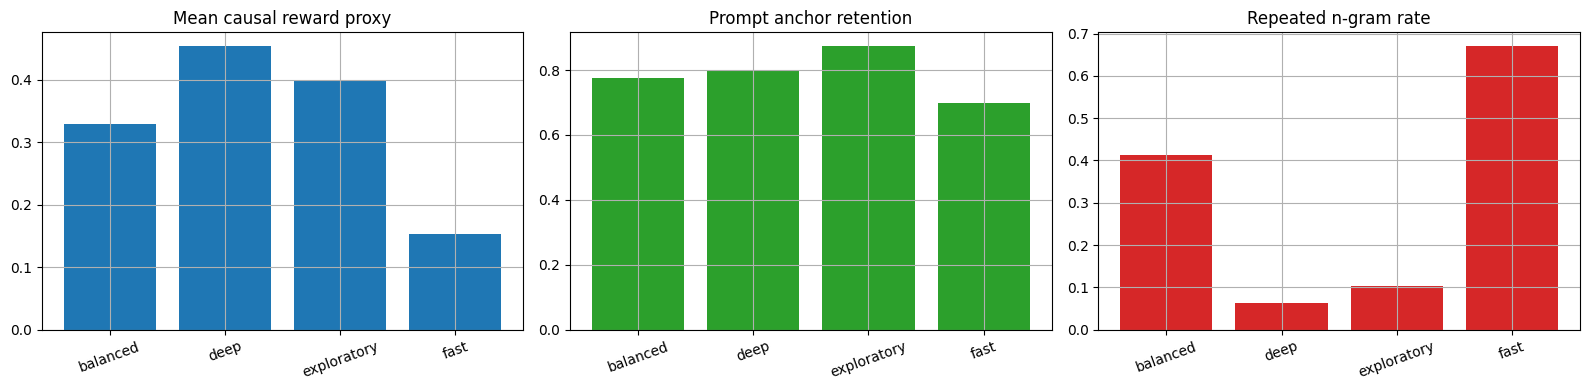

In [9]:
if len(df):
    summary = df.groupby("name")[["answer_correct", "prompt_anchor_score", "redundancy", "causal_reward", "seconds"]].mean().reset_index()
    display(summary)

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].bar(summary["name"], summary["causal_reward"])
    ax[0].set_title("Mean causal reward proxy")
    ax[0].tick_params(axis="x", rotation=20)

    ax[1].bar(summary["name"], summary["prompt_anchor_score"], color="tab:green")
    ax[1].set_title("Prompt anchor retention")
    ax[1].tick_params(axis="x", rotation=20)

    ax[2].bar(summary["name"], summary["redundancy"], color="tab:red")
    ax[2].set_title("Repeated n-gram rate")
    ax[2].tick_params(axis="x", rotation=20)
    plt.tight_layout()
else:
    print("No generations yet.")

## Inspect Outputs

Read these manually. The automated metrics are only triage. Your thesis target is the first denoising regime where the output remains fluent but no longer tracks the causal intervention correctly.

In [10]:
if len(df):
    for _, row in df.sort_values(["pair_id", "variant", "steps"]).iterrows():
        print("=" * 100)
        print(row["pair_id"], row["variant"], row["name"], "reward", round(row["causal_reward"], 3))
        print("PROMPT:", row["prompt"])
        print("COMPLETION:", row["completion"][:1200])
else:
    print("No generations yet.")

count_intervention base fast reward 0.246
PROMPT: There are 18 apples. 6 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.
COMPLETION: output: To determine how many apples each child gets, we need to follow these steps:

1. Calculate the<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|>. Divide the remaining apples equally among the 4 children.

First, we<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|>\[ 18 - 6 = 12 \<|fim_pad|>So,<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|> equally among the 4 children:
\[ 12 \div 4 = 3 \]

Therefore, each child gets \(\boxed{3}

## Next Experiment

The next step is to replace these text-level proxies with trajectory-level signals from the DLM internals:

- per-step confidence or entropy if exposed by the model code
- token change rate across denoising steps
- answer-token stabilization time
- correlation between changed prompt variables and changed generated answer tokens
- reward shaping that penalizes schedules where output remains fluent but counterfactual sensitivity fails

A stronger causal reward would look like:

$$R = \mathbf{1}[\hat y = y] \cdot \exp(-\lambda L_{drift}) \cdot \exp(-\mu L_{inv}) \cdot \exp(-\nu L_{redundancy})$$

where `L_drift` penalizes loss of prompt-state anchors, `L_inv` penalizes failure under counterfactual prompt edits, and `L_redundancy` penalizes repetitive denoising tails.